In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Download stock data
stock = "AAPL"

df = yf.download(stock, start="2020-01-01", end="2025-01-01")

# Display first rows
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333870  72.394078  71.091176  71.344047  135480400
2020-01-03  71.630638  72.389257  71.406666  71.563205  146322800
2020-01-06  72.201439  72.239973  70.503576  70.754043  118387200
2020-01-07  71.861855  72.466338  71.642697  72.211056  108872000
2020-01-08  73.017822  73.318862  71.565606  71.565606  132079200


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB
None
Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1258.000000  1258.000000  1258.000000  1258.000000  1.258000e+03
mean     151.377786   152.899566   149.680872   151.223470  9.057103e+07
std       41.851998    41.992362    41.629302    41.795804  5.324438e+07
min       54.163696    55.160694    51.324793    55.059305  2.323470e+07
25%      126.279114   127.397089   124.278513   125.724400  5.54682

In [4]:
print(df.isnull().sum())

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


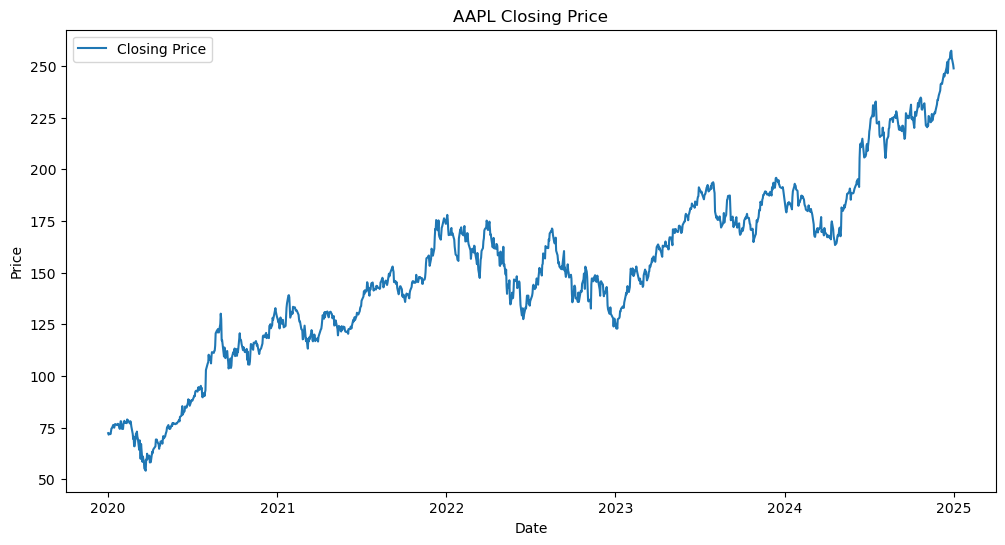

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Closing Price')
plt.title(f'{stock} Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

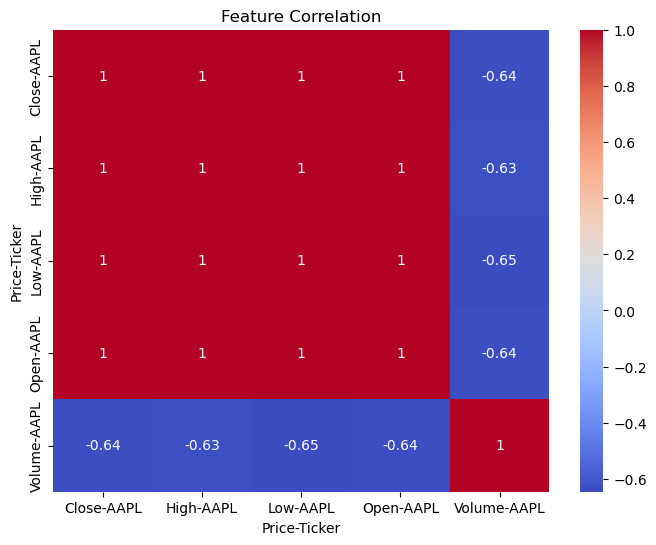

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [7]:
# Create target column
df['Target'] = df['Close'].shift(-1)

# Remove last row with NaN target
df = df.dropna()

In [8]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [10]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, lr_predictions)
mse = mean_squared_error(y_test, lr_predictions)
r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

Linear Regression Results
MAE: 2.3319135022944324
MSE: 9.602468522495002
R2 Score: 0.9852342836841449


In [12]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [13]:
mae_rf = mean_absolute_error(y_test, rf_predictions)
mse_rf = mean_squared_error(y_test, rf_predictions)
r2_rf = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 19.185236859397286
MSE: 669.293470411445
R2 Score: -0.02917260212811934


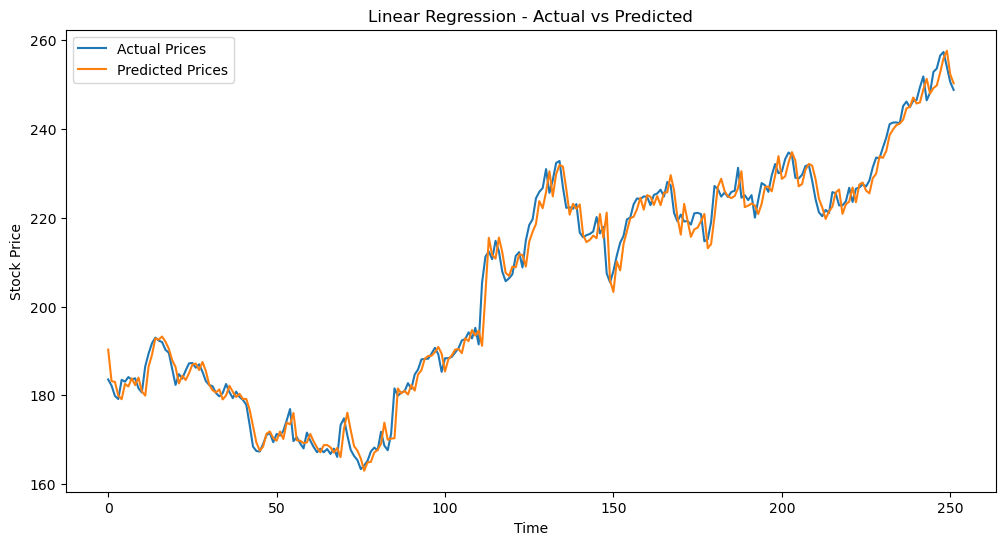

In [14]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Prices')
plt.plot(lr_predictions, label='Predicted Prices')

plt.title('Linear Regression - Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()

plt.show()

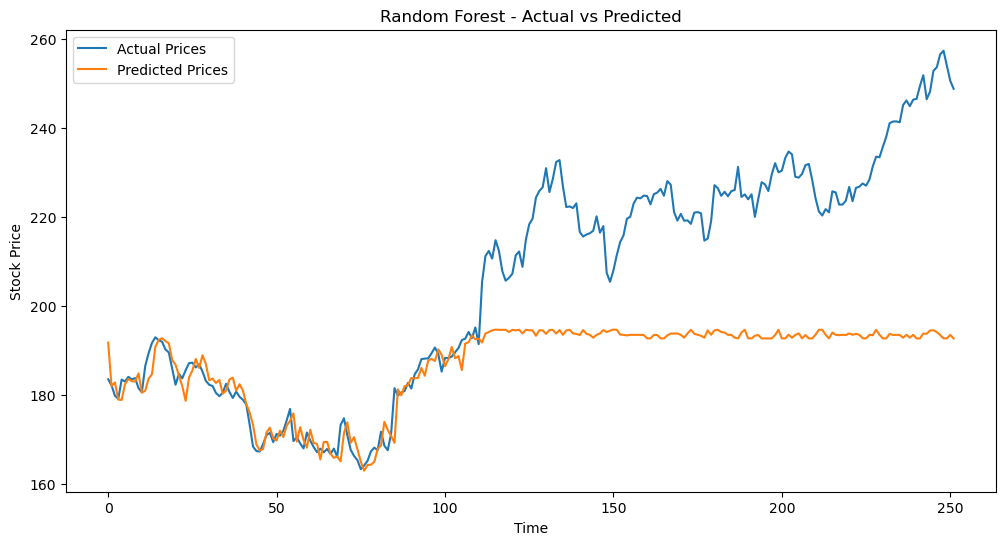

In [15]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Prices')
plt.plot(rf_predictions, label='Predicted Prices')

plt.title('Random Forest - Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()

plt.show()

In [16]:
Conclusion:
- Random Forest performed better than Linear Regression.
- The model successfully captured short-term stock price trends.
- Volume and price-based features were useful predictors.
- Stock prices are highly volatile, so predictions are not perfectly accurate.

SyntaxError: invalid syntax (4115698354.py, line 1)